# Distribuições de Probabilidade


- Bernoulli e Binomial. 
- Exponencial. 
- Gaussiana (Normal). 
- Rayleigh e Rice. 
- Poisson.

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli, binom, expon, norm, rayleigh, rice, poisson

---

##  Bernoulli

Distribuição discreta que modela um experimento com dois resultados possíveis: sucesso (1) ou fracasso (0).

$$
P(X = x) = p^x (1 - p)^{1-x}, \quad x \in \{0,1\}
$$



---

## Binomial

Modela o número de sucessos em \(n\) tentativas independentes. Calcula a probabilidade de obter k sucessos em n tentativas independentes de um experimento de Bernoulli. Ex: Uma moeda tem duas faces: cara e coroa, podemos repetir o experimento de Bernoulli n vezes (Jogar a moeda n vezes).

$$
P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k = 0,1,\dots,n
$$


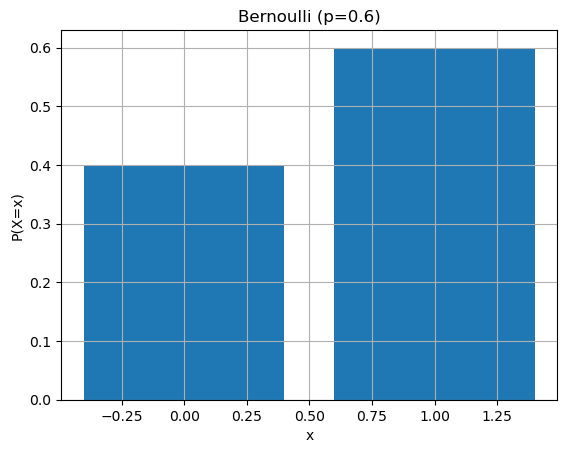

In [106]:
p = 0.6 # probabilidade de sucesso P(X=1)=0.6
x = np.array([0, 1]) # assumir dois valores 0 fracasso  e 1 sucesso
y = bernoulli.pmf(x, p) # probability mass function da distribuição de Bernoulli

plt.figure()
plt.bar(x, y)
plt.title("Bernoulli (p=0.6)")
plt.xlabel("x")
plt.ylabel("P(X=x)")
plt.grid()
plt.show()

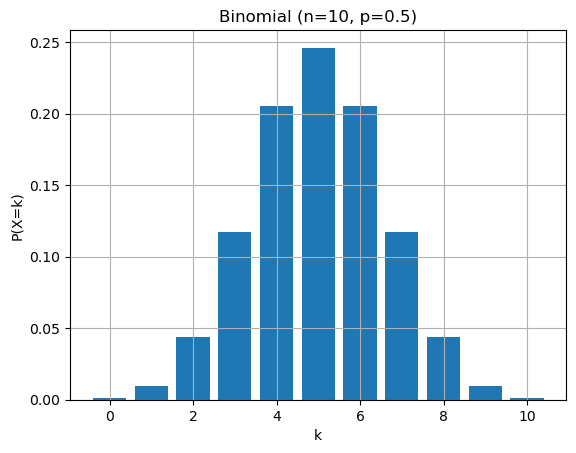

In [107]:
n, p = 10, 0.5 # número de tentativas (experimentos) e probabilidade de sucesso em cada tentativa
# repete-se um experimento 10 vezes e cada vez tem 50% de chance de sucesso
x = np.arange(0, n+1) # gera os valores de 0 até 10
y = binom.pmf(x, n, p)

# O valor mais provável é k=5, com chance de 50%, o mais esperado é metade dar sucesso.

plt.figure()
plt.bar(x, y)
plt.title("Binomial (n=10, p=0.5)")
plt.xlabel("k")
plt.ylabel("P(X=k)")
plt.grid()
plt.show()

## Modelagem com distribuição Binomial

- Modela experimentos com dois resultados possíveis (sucesso/falha).

- Aplicada à análise de erros de bits (Bit Error Rate – BER) em sistemas de comunicação digital, onde cada bit transmitido pode ser correto ou corrompido.

- Também usada para modelar falhas de nós em redes de sensores sem fio (WSN), já que cada nó pode estar ativo ou falhar por esgotamento de energia

## Aplicação: Detecção de erro em pacotes de rede

Em redes de computadores, cada pacote transmitido pode:

- chegar corretamente (sucesso)
- chegar corrompido (erro)

Cada pacote pode ser modelado como uma variável aleatória:

$$
X = 
\begin{cases}
1, & \text{pacote íntegro} \\
0, & \text{pacote corrompido}
\end{cases}
$$

com:

$$
P(X = 1) = p
$$

- \( p \) = probabilidade de transmissão correta  
- \( 1 - p \) = taxa de erro do canal  


- avaliação da qualidade de um canal de comunicação  
- detecção de falhas em protocolos (ex: TCP, UDP)  
- análise de confiabilidade de redes  

---

## Aplicação: Ativação de genes em células
Após um estímulo químico:
- cada gene pode ser ativado ou não
- diferentes células respondem de forma probabilística

- permite estimar a resposta celular  
- modela variabilidade entre células  
- usado em bioinformática e análise de expressão gênica  

---

## Aplicação: Cliques em interfaces (UX)

Em sistemas digitais (apps, sites):

- cada usuário pode clicar ou não em um elemento  
- cada interação é incerta

---

Cada interação:

$$
X_i =
\begin{cases}
1, & \text{clique} \\
0, & \text{sem clique}
\end{cases}
$$

Para múltiplos usuários:

$$
X = \sum_{i=1}^{n} X_i \sim \text{Binomial}(n, p)
$$



---

## Exponencial

Distribuição contínua que descreve o tempo entre eventos.

$$
f(x) = \lambda e^{-\lambda x}, \quad x \ge 0
$$


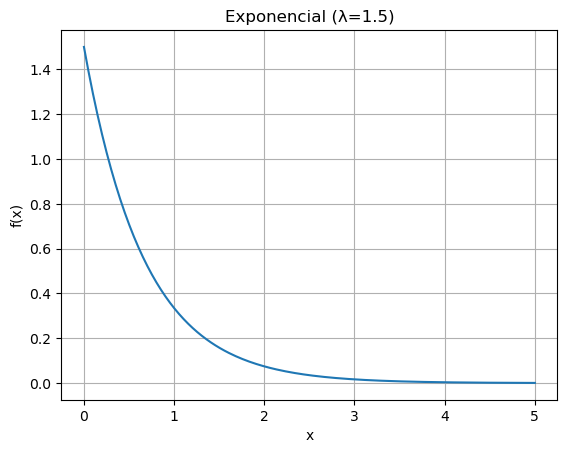

In [108]:
lam = 1.5 # Define a taxa λ da distribuição.
x = np.linspace(0, 5, 200) # 200 pontos espaçados entre 0 e 5
y = expon.pdf(x, scale=1/lam)  #  função densidade de probabilidade da exponencial
# tem alta chance de eventos acontecerem rapidamente
# probabilidade diminui para tempos maiores

plt.figure()
plt.plot(x, y)
plt.title("Exponencial (λ=1.5)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()

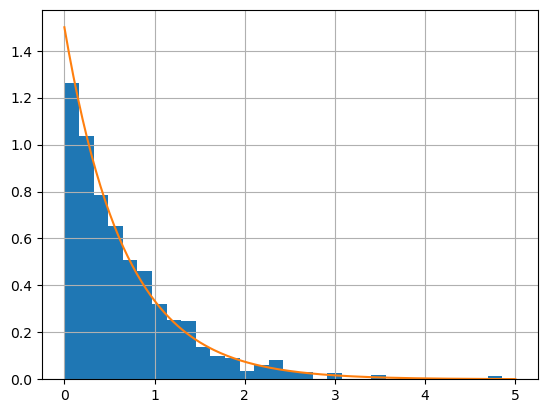

In [109]:
samples_exp = np.random.exponential(1/1.5, 1000)
x = np.linspace(0, 5, 200)
pdf = expon.pdf(x, 0, scale=1/1.5)

plt.hist(samples_exp, bins=30, density=True)
plt.plot(x, pdf)
plt.grid()
plt.show()

# Uso da Distribuição Exponencial

A distribuição exponencial é utilizada para modelar:

## Tempo entre a chegada de pacotes em uma rede

Embora a distribuição exponencial seja teoricamente adequada para modelar tempos entre eventos aleatórios, ela não captura bem o comportamento real do tráfego de rede, que apresenta:
- rajadas (burstiness)
- dependência temporal

http://dx.doi.org/10.5755/j01.eee.20.3.6683

## Tempo até a falha de um sistema ou componente

Modela o tempo de falha de máquinas ATM - Automated Teller Machine (caixa eletrônico) usando a distribuição exponencial.

http://www.ss-pub.org/wp-content/uploads/2018/05/JMSS17121401.pdf

## Tempo até perda de foco em tarefas cognitivas repetitivas

Em atividades mentais repetitivas:

- a perda de foco pode ser vista como um evento aleatório  
- o tempo até a distração pode ser modelado por uma exponencial  

Isso reflete que:
- a chance de perder o foco é aproximadamente constante ao longo do tempo  
- não depende de quanto tempo a pessoa já está concentrada  


https://doi.org/10.1177/001872088702900603




---

## Normal (Gaussiana)

Distribuição contínua simétrica em torno da média.

$$
f(x) = \frac{1}{\sigma \sqrt{2\pi}} \; e^{-\frac{(x - \mu)^2}{2\sigma^2}}, \quad x \in \mathbb{R}
$$


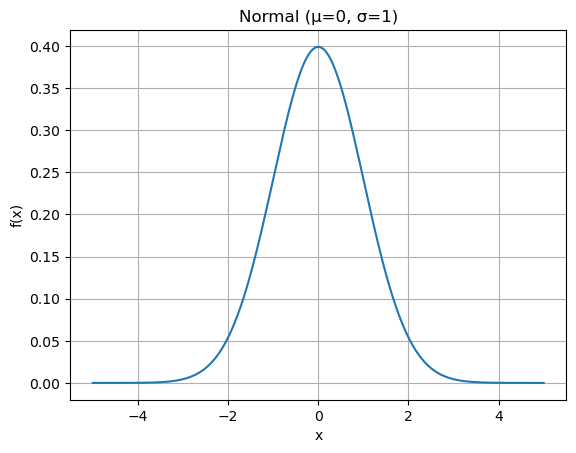

In [ ]:
mu, sigma = 0, 1 # média: centro da distribuição e  desvio padrão: controla a “largura” da curva
x = np.linspace(-5, 5, 300) # 300 pontos entre -5 e 5
y = norm.pdf(x, loc=mu, scale=sigma) #  função densidade de probabilidade da normal

plt.figure()
plt.plot(x, y)
plt.title("Normal (μ=0, σ=1)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()

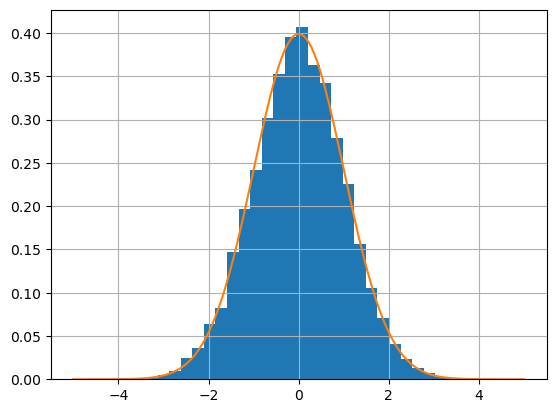

In [111]:
samples_normal = np.random.normal(0, 1, 10000)
x = np.linspace(-5, 5, 200)
pdf = norm.pdf(x, 0, 1)

plt.hist(samples_normal, bins=30, density=True)
plt.plot(x, pdf)
plt.grid()
plt.show()

# Uso da Distribuição Normal

## Ruído em sensores de smartphones

Sensores como:

- acelerômetro  
- giroscópio  

não medem valores perfeitamente — sempre existe um **erro de medição (ruído)**.

Esse ruído geralmente é modelado como gaussiano porque:

- resulta de várias pequenas fontes de erro (vibração, temperatura, eletrônica)  
- essas perturbações se somam  

Consequência:
- leituras oscilam em torno do valor real  
- erros grandes são raros, erros pequenos são comuns  

## Tempo de reação humana

O tempo de resposta a estímulos (visual, auditivo, etc.) varia entre tentativas:

- pequenas variações fisiológicas  
- atenção  
- fadiga  

Esses fatores se combinam, gerando uma distribuição aproximadamente normal:

- maioria dos tempos perto da média  
- poucos muito rápidos ou muito lentos  


## Analise da distribuição dos erros de modelos de Machine Learning aplicados a dados de química quântica.

Em modelos de Machine Learning, é comum assumir que os erros de predição seguem uma distribuição normal

Em muitos modelos (especialmente regressão), assume-se que:

$$
\epsilon = y - \hat{y} \sim \mathcal{N}(0, \sigma^2)
$$

ou seja, o erro segue uma distribuição normal.

Isso acontece porque:

- erros vêm de múltiplas fontes pequenas  
- não há viés sistemático (centrados em zero)

https://doi.org/10.1021/acs.jcim.1c00503

## Uso da distribuição Gaussiana e aprendizado de máquina para detectar anomalias em sistemas de monitoramento na saúde que utilizam sensores conectados à nuvem

Melhora a capacidade do sistema de reconhecer desvios significativos nos dados de sensores

https://doi.org/10.4018/ijcac.2021010103



### A distribuição normal é adequada quando:

- há muitos fatores aleatórios pequenos  
- os efeitos se somam  
- os dados se concentram em torno de um valor médio  


---

## Rayleigh

Distribuição contínua associada à magnitude de vetores com componentes gaussianas.

$$
f(x) = \frac{x}{\sigma^2} e^{-x^2/(2\sigma^2)}, \quad x \ge 0
$$

---

## Rice

Generalização da Rayleigh com componente determinística.

$$
f(x) = \frac{x}{\sigma^2} e^{-(x^2 + \nu^2)/(2\sigma^2)} I_0\left(\frac{x\nu}{\sigma^2}\right), \quad x \ge 0
$$

onde $I_0(\cdot)$ é a função de Bessel modificada de ordem zero.


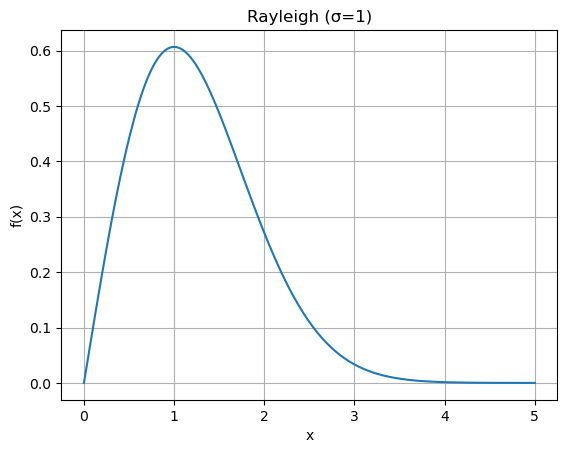

In [112]:
sigma = 1
x = np.linspace(0, 5, 200)
y = rayleigh.pdf(x, scale=sigma)

plt.figure()
plt.plot(x, y)
plt.title("Rayleigh (σ=1)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()

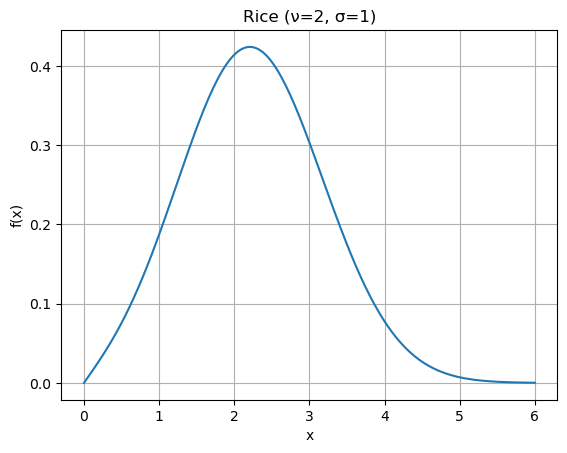

In [113]:
nu, sigma = 2, 1
x = np.linspace(0, 6, 200)

# parâmetro "b" = nu/sigma
y = rice.pdf(x, b=nu/sigma, scale=sigma)

plt.figure()
plt.plot(x, y)
plt.title("Rice (ν=2, σ=1)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()

# Uso da Distribuição de Rayleigh / Rice

## Sinais de comunicação (Wi-Fi) - Modelagem de canais com desvanecimento Rayleigh

Em sistemas sem fio:

- o sinal recebido é a soma de:
  - um caminho direto (linha de visada – LoS)  
  - múltiplos caminhos refletidos (ruído/multipercurso)  

Quando existe um caminho dominante:

a intensidade do sinal segue uma distribuição de Rice

---
- o sinal não é totalmente aleatório  
- existe uma direção preferencial (componente forte)  
- a variabilidade ainda existe por causa do ruído  

Aplicação:
- modelagem de canais wireless  
- análise de qualidade de sinal  
- sistemas 4G/5G, Wi-Fi  

https://www.ijrdet.com/files/Volume2Issue2/IJRDET_0214_27.pdf


## Imagens médicas (MRI)

Em imagens de ressonância magnética (MRI):

- o sinal medido tem componentes real e imaginária com ruído gaussiano  
- a imagem final usa a **magnitude do sinal**

Resultado:

- sem sinal dominante → distribuição Rayleigh  
- com sinal forte → distribuição Rice  

---

- melhora reconstrução de imagem  
- ajuda a reduzir ruído  
- aumenta precisão diagnóstica  

---

## Melhorar a detecção de mudanças em imagens multispectrais e multitemporais, usadas em sensoriamento remoto

https://doi.org/10.1109/TIP.2015.2474710


---

## Poisson

Distribuição discreta que modela o número de eventos em um intervalo fixo.

$$
P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad k = 0,1,2,\dots
$$

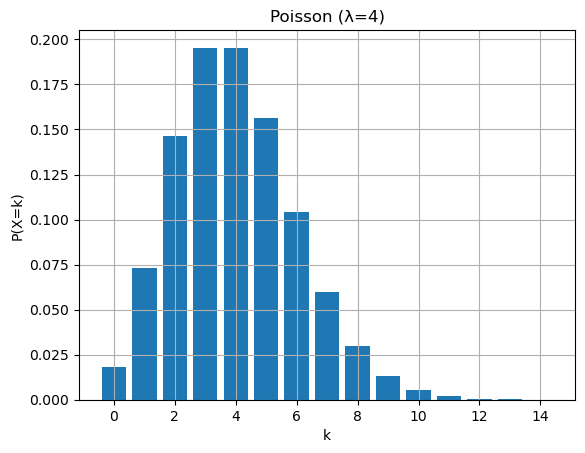

In [ ]:
lam = 4 # número médio de eventos por intervalo
x = np.arange(0, 15)
y = poisson.pmf(x, lam) # Calcula a função de probabilidade

plt.figure()
plt.bar(x, y)
plt.title("Poisson (λ=4)")
plt.xlabel("k")
plt.ylabel("P(X=k)")
plt.grid()
plt.show()

# Uso da Distribuição de Poisson

## Erros detectados em software ao longo do tempo
A distribuição de Poisson é usada para modelar o número de erros detectados em software ao longo do tempo:

Durante testes de software:

- erros (bugs) são encontrados ao longo do tempo  
- cada detecção pode ser vista como um evento  

A variável:

$$
X = \text{número de erros detectados em um intervalo}
$$

pode ser modelada por uma distribuição de Poisson.


- no início → muitos erros (taxa maior)  
- depois → menos erros (taxa menor, em versões mais avançadas usa-se Poisson não homogêneo)  

---

https://doi.org/10.1081/SAC-100105083


## Distribuição de Poisson em Bioinformática - Ocorrência de padrões em sequências biológicas

A distribuição de Poisson é usada para modelar o número de ocorrências de padrões em sequências biológicas

Calcular a probabilidade de uma sequência gerar outra

Em bioinformática:
- analisa-se sequências de DNA/proteínas  
- conta-se quantas vezes um padrão aparece (ex: "ATG")

Se o padrão for raro e a sequência for longa:

$$
X = \text{número de ocorrências do padrão}
$$

pode ser modelado por uma Poisson.


- padrões comuns aparecem frequentemente  
- padrões raros seguem comportamento probabilístico  

Aplicação:
- comparação genética  
- análise de similaridade entre sequências  
- filogenia  

https://doi.org/10.1016/j.mbs.2008.11.006